# CV_PR3 — Deep Learning / Computer Vision Practical

**Student-friendly complete notebook template**

This notebook follows the project sheet in the uploaded PR3 document and keeps the task order:

1. Environment setup, image loading & morphological operations
2. Bitwise operations & image histograms
3. Face detection with YuNet (OpenCV)
4. Object detection with YOLOv8n
5. Integrated pipeline & final comparison
6. Viva questions and short answers

> **Important:** Run the notebook from top to bottom. Put your own images in `data/images/`. The notebook creates `data/models/` automatically for the YuNet model. YOLOv8n weights are downloaded automatically by Ultralytics on first use.

**Project file name:** `CV_PR3.ipynb`


## Dataset / files required

Recommended folder structure:

```text
CV_PR3/
├── CV_PR3.ipynb
├── data/
│   ├── images/
│   │   ├── morphology.jpg
│   │   ├── bitwise.jpg
│   │   ├── face1.jpg
│   │   ├── face2.jpg
│   │   ├── objects1.jpg
│   │   └── objects2.jpg
│   └── models/
│       └── face_detection_yunet_2023mar.onnx
├── plots/
└── requirements.txt
```

Use **3–4 face images** with different pose/lighting/occlusion for YuNet and **2–3 object images** containing COCO objects such as person, car, dog, bottle, chair, etc.


In [ ]:


import os
import time
import urllib.request
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)

# Folders
BASE = Path.cwd()
DATA_DIR = BASE / "data"
IMG_DIR = DATA_DIR / "images"
MODEL_DIR = DATA_DIR / "models"
PLOTS_DIR = BASE / "plots"

for folder in [IMG_DIR, MODEL_DIR, PLOTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Image folder:", IMG_DIR)
print("Model folder:", MODEL_DIR)
print("Plots folder:", PLOTS_DIR)


OpenCV version: 5.0.0
NumPy version: 2.2.5
Image folder: c:\Deep Learning\PR-3\data\images
Model folder: c:\Deep Learning\PR-3\data\models
Plots folder: c:\Deep Learning\PR-3\plots


In [2]:
# Helper functions
def show(img, title="", cmap=None, figsize=(8, 6)):
    plt.figure(figsize=figsize)
    if len(img.shape) == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap or "gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

def savefig(name):
    path = PLOTS_DIR / name
    plt.savefig(path, bbox_inches="tight", dpi=150)
    print("Saved:", path)

def load_image(filename):
    path = IMG_DIR / filename
    img = cv2.imread(str(path))
    if img is None:
        raise FileNotFoundError(f"Image not found: {path}")
    print(f"{filename}: shape={img.shape}, dtype={img.dtype}")
    return img

image_files = sorted([p.name for p in IMG_DIR.glob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]])
print("Images found:", image_files)


Images found: ['face1.jpg', 'face2.jpg', 'face3.jpg', 'fruits.png', 'morphology.jpg', 'objects1.jpg', 'objects2.jpg']


# Task 1 — Environment Setup, Image Loading & Morphological Operations

### Objective
Understand how erosion, dilation, opening and closing can clean or modify a binary image before a detector receives it.

### Expected output
A binary image, a 1×5 morphology comparison, a 3×3 kernel-shape/size comparison grid, and a Markdown explanation of the four operations.


morphology.jpg: shape=(3472, 2747, 3), dtype=uint8
Saved: c:\Deep Learning\PR-3\plots\task1_binary.png


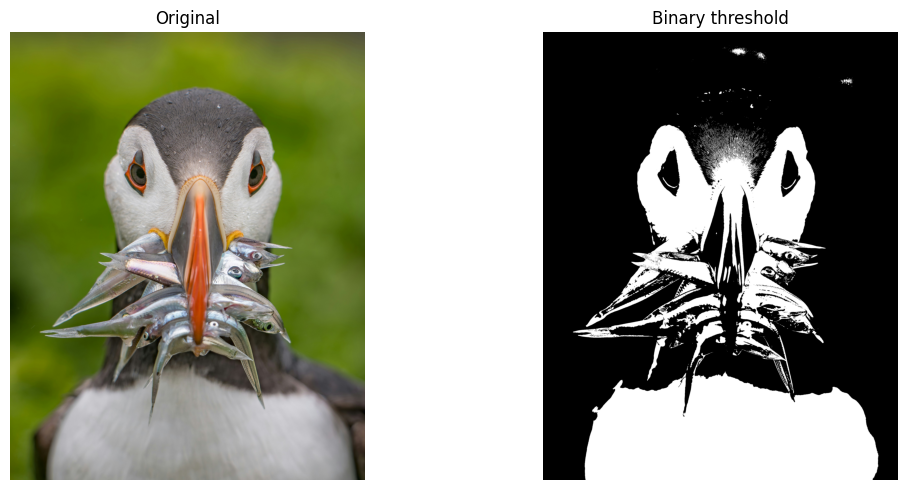

In [ ]:

morph_name = "morphology.jpg" if (IMG_DIR / "morphology.jpg").exists() else (image_files[0] if image_files else None)

if morph_name is None:
    raise FileNotFoundError("Add at least one image to data/images/.")

img = load_image(morph_name)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Required binary threshold: threshold=127, maxval=255
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(binary, cmap="gray")
plt.title("Binary threshold")
plt.axis("off")
plt.tight_layout()
savefig("task1_binary.png")
plt.show()


Saved: c:\Deep Learning\PR-3\plots\task1_morphology_1x5.png


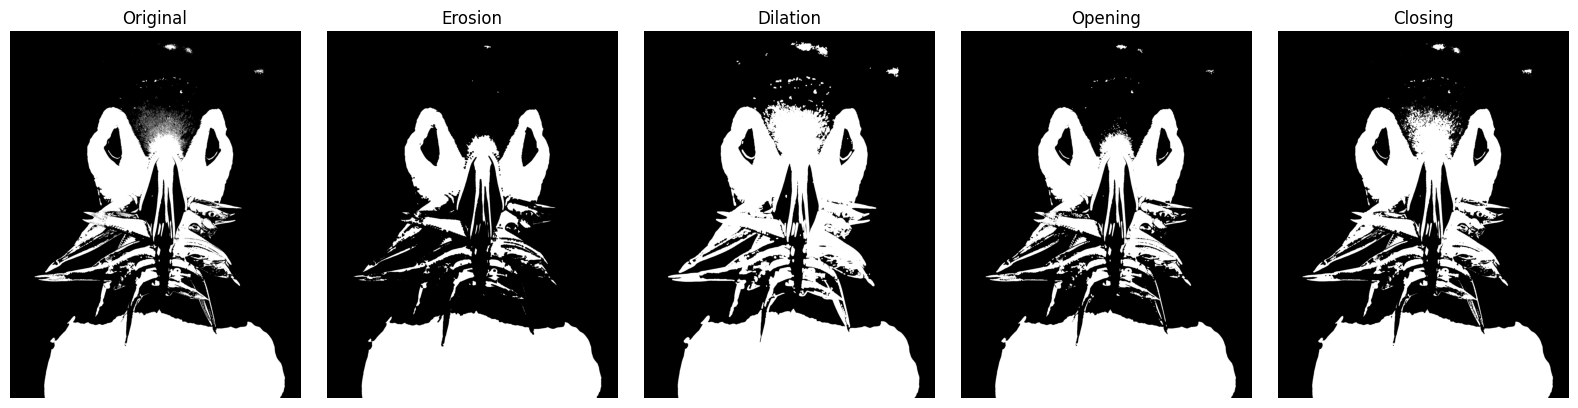

In [ ]:
kernel = np.ones((5, 5), np.uint8)

eroded = cv2.erode(binary, kernel, iterations=2)
dilated = cv2.dilate(binary, kernel, iterations=2)
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

results = [
    ("Original", binary),
    ("Erosion", eroded),
    ("Dilation", dilated),
    ("Opening", opened),
    ("Closing", closed),
]

plt.figure(figsize=(16, 4))
for i, (title, result) in enumerate(results, 1):
    plt.subplot(1, 5, i)
    plt.imshow(result, cmap="gray")
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
savefig("task1_morphology_1x5.png")
plt.show()


### Why morphology works

- **Erosion:** shrinks white foreground regions. It removes small white noise and is useful when objects have tiny unwanted protrusions. It behaves like a local minimum operation for binary/grayscale morphology.
- **Dilation:** expands white foreground regions. It can fill small gaps, connect nearby components and recover thin parts after erosion.
- **Opening = erosion → dilation:** removes small bright/salt noise while preserving the main shape reasonably well. A practical use is cleaning a noisy foreground mask before detection.
- **Closing = dilation → erosion:** fills small dark holes and gaps inside foreground objects. A practical use is repairing broken regions in a segmentation mask before passing it downstream.

For a noisy camera mask, **opening** is usually useful for removing small isolated white noise, while **closing** is useful for filling small holes or broken dark regions.


Saved: c:\Deep Learning\PR-3\plots\task1_kernel_comparison.png


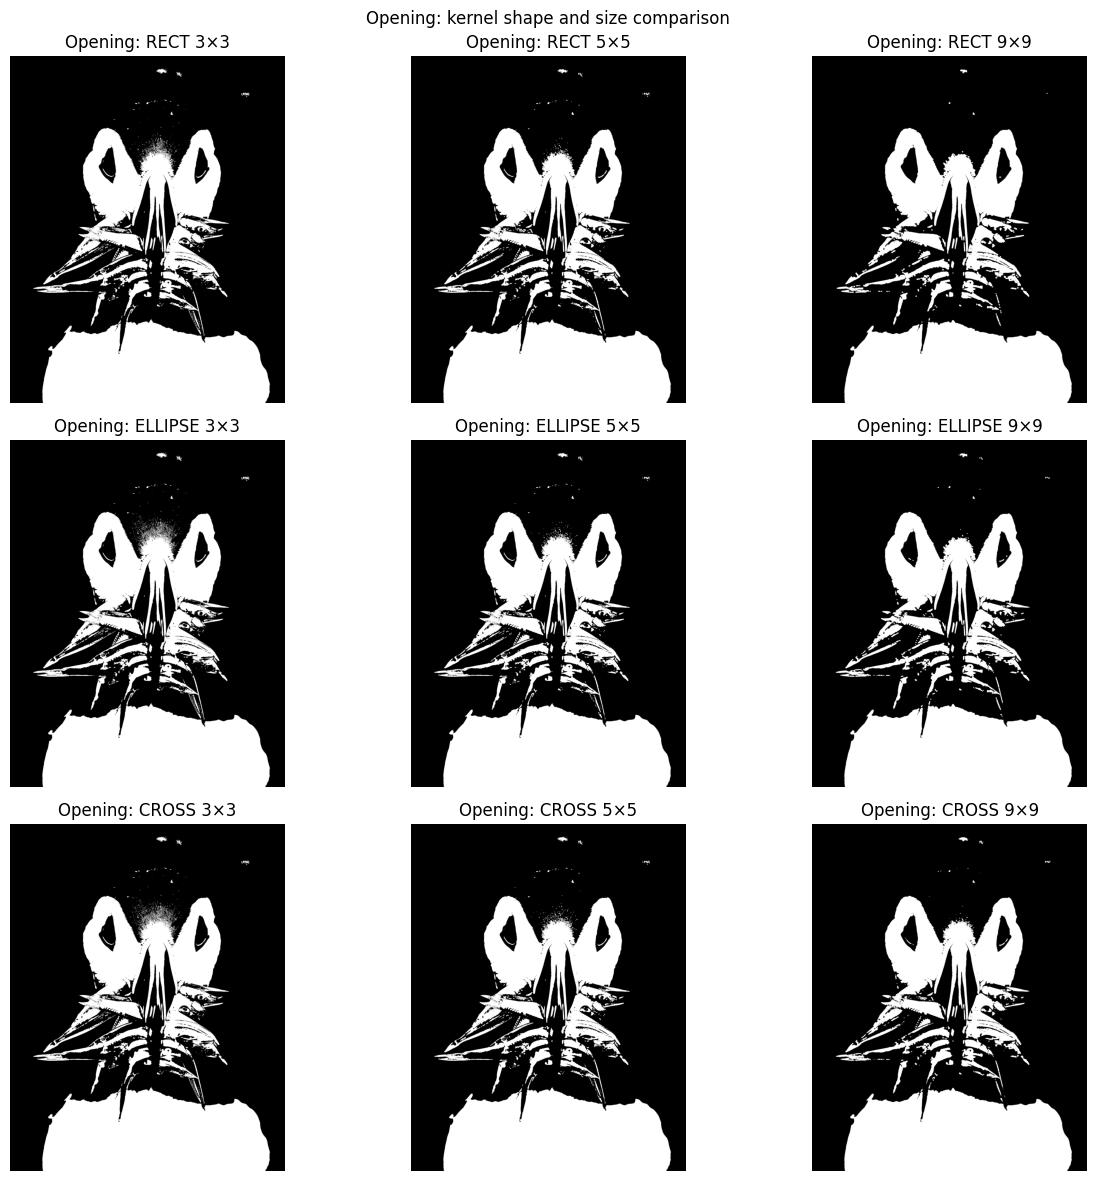

Tip: For salt-and-pepper noise, choose the smallest kernel that removes noise without noticeably shrinking object boundaries.


In [ ]:


shapes = {
    "RECT": cv2.MORPH_RECT,
    "ELLIPSE": cv2.MORPH_ELLIPSE,
    "CROSS": cv2.MORPH_CROSS,
}
sizes = [3, 5, 9]

plt.figure(figsize=(13, 12))
plot_no = 1

for shape_name, shape_code in shapes.items():
    for size in sizes:
        k = cv2.getStructuringElement(shape_code, (size, size))
        opened_k = cv2.morphologyEx(binary, cv2.MORPH_OPEN, k)
        closed_k = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, k)

        # Show opening for comparison
        ax = plt.subplot(3, 3, plot_no)
        ax.imshow(opened_k, cmap="gray")
        ax.set_title(f"Opening: {shape_name} {size}×{size}")
        ax.axis("off")
        plot_no += 1

plt.suptitle("Opening: kernel shape and size comparison")
plt.tight_layout()
savefig("task1_kernel_comparison.png")
plt.show()

print("Tip: For salt-and-pepper noise, choose the smallest kernel that removes noise without noticeably shrinking object boundaries.")


# Task 2 — Bitwise Operations & Image Histograms

### Objective
Use binary masks for logical image operations and use histograms to understand intensity distribution, brightness and contrast.

### Expected output
A 2×3 bitwise grid, a masked-image example, grayscale and B/G/R histograms, and brightness/contrast comparisons.


Saved: c:\Deep Learning\PR-3\plots\task2_bitwise_grid.png


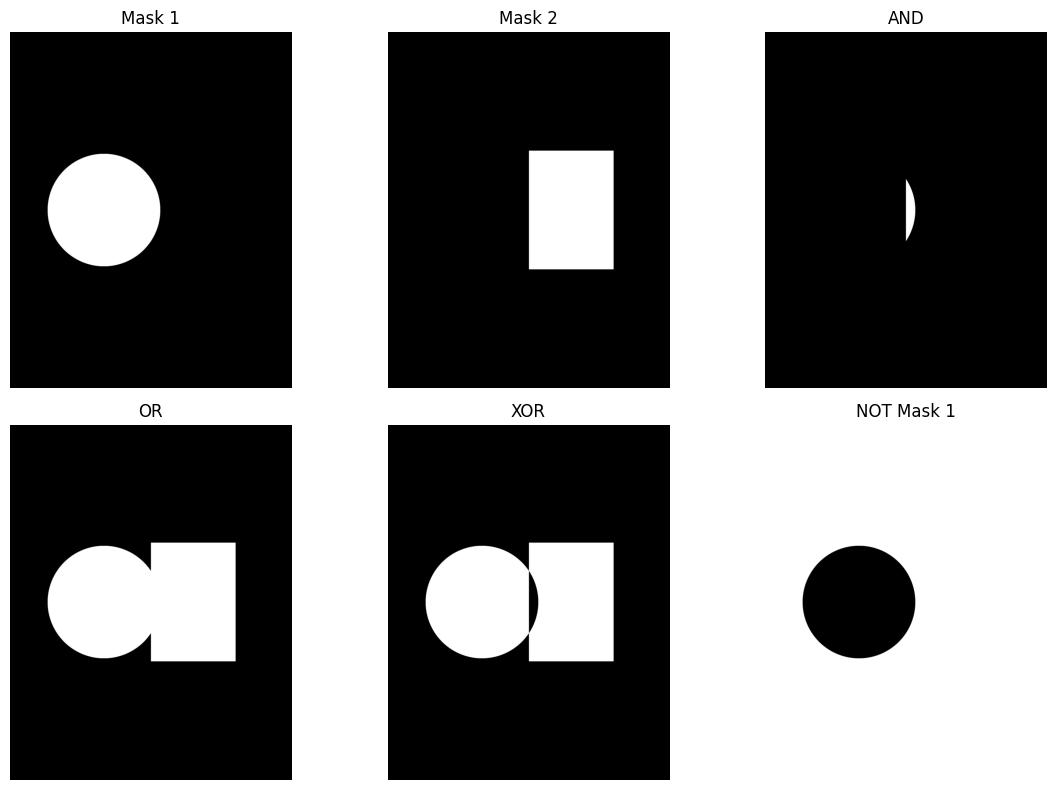

In [ ]:
canvas_shape = binary.shape if 'binary' in globals() else (400, 600)
mask1 = np.zeros(canvas_shape, dtype=np.uint8)
mask2 = np.zeros(canvas_shape, dtype=np.uint8)

h, w = canvas_shape[:2]
cv2.circle(mask1, (w//3, h//2), min(h, w)//5, 255, -1)
cv2.rectangle(mask2, (w//2, h//3), (w*4//5, h*2//3), 255, -1)

bit_and = cv2.bitwise_and(mask1, mask2)
bit_or = cv2.bitwise_or(mask1, mask2)
bit_xor = cv2.bitwise_xor(mask1, mask2)
bit_not = cv2.bitwise_not(mask1)

items = [
    ("Mask 1", mask1), ("Mask 2", mask2),
    ("AND", bit_and), ("OR", bit_or),
    ("XOR", bit_xor), ("NOT Mask 1", bit_not)
]

plt.figure(figsize=(12, 8))
for i, (title, im) in enumerate(items, 1):
    plt.subplot(2, 3, i)
    plt.imshow(im, cmap="gray")
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
savefig("task2_bitwise_grid.png")
plt.show()


Saved: c:\Deep Learning\PR-3\plots\task2_masked_region.png


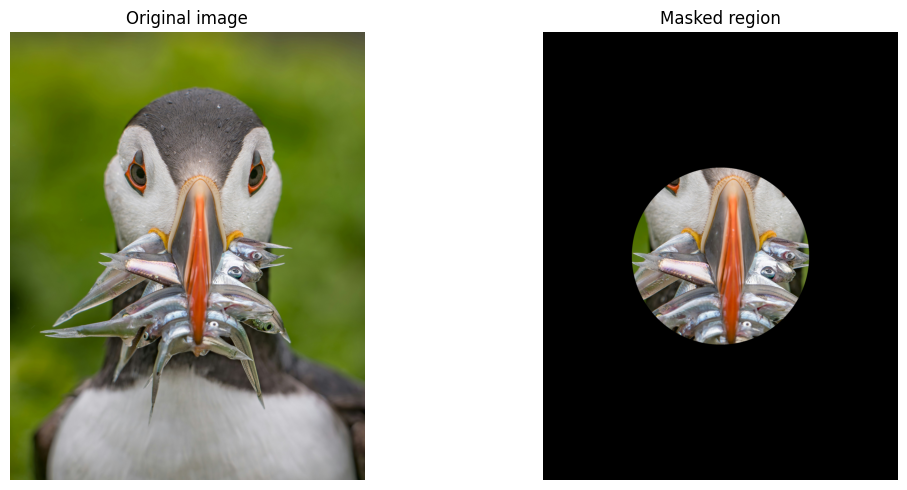

In [ ]:
source = img.copy()

roi_mask = np.zeros(source.shape[:2], dtype=np.uint8)
center = (source.shape[1]//2, source.shape[0]//2)
radius = min(source.shape[:2]) // 4
cv2.circle(roi_mask, center, radius, 255, -1)

masked_region = cv2.bitwise_and(source, source, mask=roi_mask)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(source, cv2.COLOR_BGR2RGB))
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(masked_region, cv2.COLOR_BGR2RGB))
plt.title("Masked region")
plt.axis("off")
plt.tight_layout()
savefig("task2_masked_region.png")
plt.show()


Saved: c:\Deep Learning\PR-3\plots\task2_grayscale_histogram.png


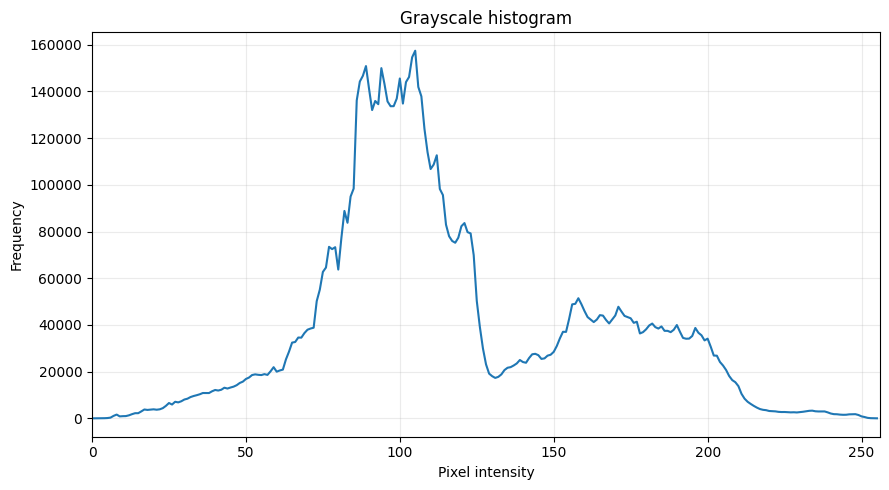

Saved: c:\Deep Learning\PR-3\plots\task2_bgr_histogram.png


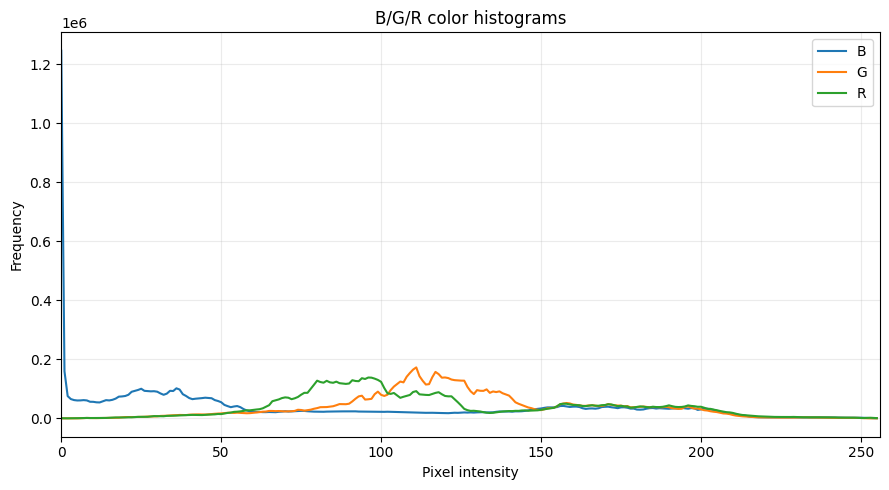

In [ ]:

gray_hist = cv2.calcHist([gray], [0], None, [256], [0, 256])

plt.figure(figsize=(9, 5))
plt.plot(gray_hist)
plt.title("Grayscale histogram")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.grid(alpha=0.25)
plt.tight_layout()
savefig("task2_grayscale_histogram.png")
plt.show()

plt.figure(figsize=(9, 5))
channel_names = [("B", 0), ("G", 1), ("R", 2)]

for name, ch in channel_names:
    hist = cv2.calcHist([source], [ch], None, [256], [0, 256])
    plt.plot(hist.ravel(), label=name)

plt.title("B/G/R color histograms")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
savefig("task2_bgr_histogram.png")
plt.show()


Saved: c:\Deep Learning\PR-3\plots\task2_brightness_contrast.png


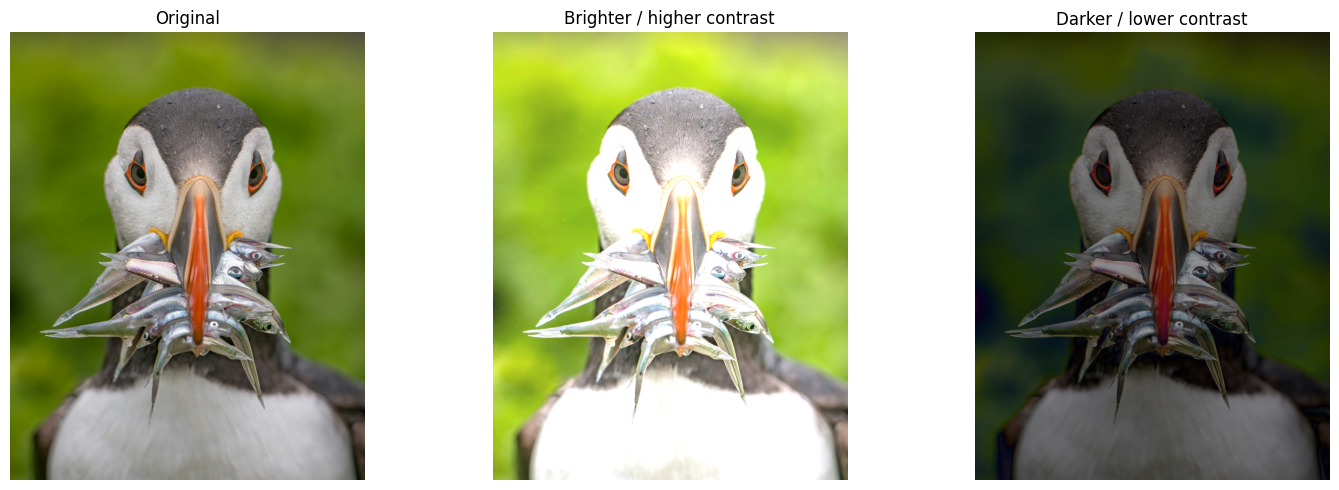

Saved: c:\Deep Learning\PR-3\plots\task2_before_after_histograms.png


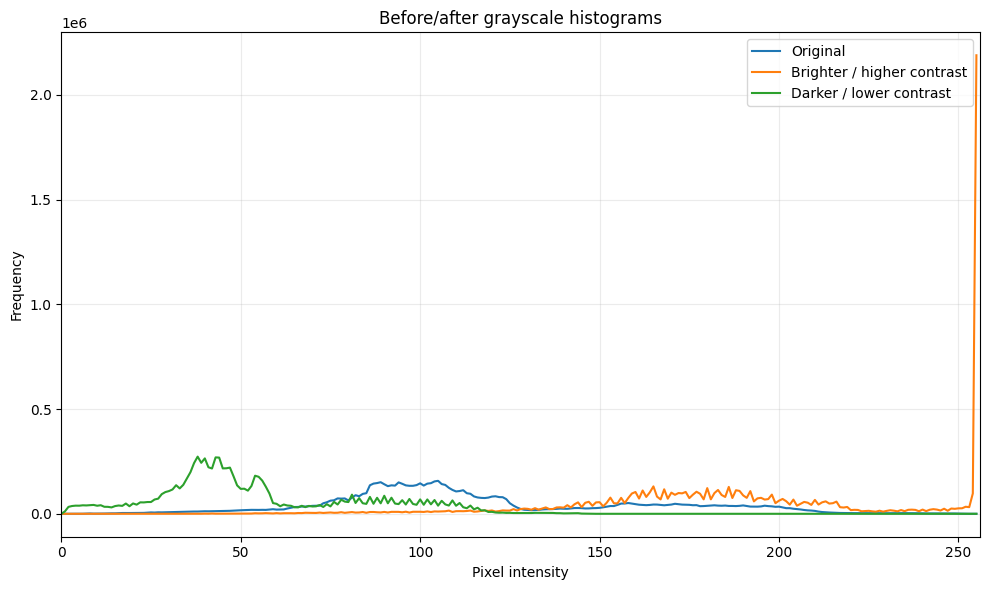

In [ ]:
bright = cv2.convertScaleAbs(source, alpha=1.5, beta=30)
dark_low_contrast = cv2.convertScaleAbs(source, alpha=0.7, beta=-30)

versions = [
    ("Original", source),
    ("Brighter / higher contrast", bright),
    ("Darker / lower contrast", dark_low_contrast),
]

plt.figure(figsize=(15, 5))
for i, (title, im) in enumerate(versions, 1):
    plt.subplot(1, 3, i)
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
savefig("task2_brightness_contrast.png")
plt.show()

# Histograms for the three versions
plt.figure(figsize=(10, 6))
for title, im in versions:
    g = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    hist = cv2.calcHist([g], [0], None, [256], [0, 256])
    plt.plot(hist.ravel(), label=title)

plt.title("Before/after grayscale histograms")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
savefig("task2_before_after_histograms.png")
plt.show()


### Why alpha and beta matter

The transformation is:

**new_pixel = alpha × pixel + beta**

- **alpha** controls contrast. Values above 1 stretch the intensity range and increase contrast; values below 1 compress the range and reduce contrast.
- **beta** controls brightness. Positive beta shifts intensities toward brighter values; negative beta shifts them darker.
- A **narrow histogram** generally indicates low contrast.
- A histogram heavily clipped near **0** can indicate under-exposure/dark clipping.
- A histogram heavily clipped near **255** can indicate over-exposure/highlight clipping.

This diagnostic is useful before face/object detection because poor contrast can make visual features harder to detect.


# Task 3 — Face Detection with YuNet (OpenCV)

### Objective
Detect faces, confidence scores and five facial landmarks using OpenCV's `FaceDetectorYN`.

### Expected output
Static-image detections, a live webcam demo, FPS measurement, confidence-threshold comparison and face-region blur/anonymisation.


In [ ]:
yunet_url = "https://github.com/opencv/opencv_zoo/raw/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx"
yunet_path = MODEL_DIR / "face_detection_yunet_2023mar.onnx"

if not yunet_path.exists():
    print("Downloading YuNet model...")
    urllib.request.urlretrieve(yunet_url, yunet_path)
    print("Downloaded:", yunet_path)
else:
    print("YuNet model already exists:", yunet_path)

print("YuNet API available:", hasattr(cv2, "FaceDetectorYN"))


Downloaded: c:\Deep Learning\PR-3\data\models\face_detection_yunet_2023mar.onnx
YuNet API available: True


In [ ]:
def create_yunet(image, score_threshold=0.9):
    h, w = image.shape[:2]
    detector = cv2.FaceDetectorYN.create(
        str(yunet_path),
        "",
        (w, h),
        score_threshold,
        0.3,
        5000
    )
    detector.setInputSize((w, h))
    return detector

def draw_yunet(image, faces):
    output = image.copy()
    if faces is None:
        return output, 0

    count = 0
    for face in faces:
        x, y, fw, fh = face[:4].astype(int)
        score = float(face[14])

        cv2.rectangle(output, (x, y), (x + fw, y + fh), (0, 255, 0), 2)

        # YuNet landmark order: right eye, left eye, nose tip, right mouth, left mouth
        landmarks = face[4:14].reshape(5, 2).astype(int)
        for px, py in landmarks:
            cv2.circle(output, (px, py), 3, (255, 0, 0), -1)

        cv2.putText(
            output, f"Face: {score:.2f}",
            (x, max(20, y - 8)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2
        )
        count += 1

    return output, count

def detect_yunet(image, score_threshold=0.9):
    detector = create_yunet(image, score_threshold)
    _, faces = detector.detect(image)
    return draw_yunet(image, faces), faces

print("YuNet helpers ready.")


YuNet helpers ready.


In [ ]:


def create_yunet(image, score_threshold=0.9):
    h, w = image.shape[:2]

    detector = cv2.FaceDetectorYN.create(
        str(yunet_path),
        "",
        (w, h),
        score_threshold,
        0.3,
        5000
    )

    detector.setInputSize((w, h))

    return detector


def draw_yunet(image, faces):

    output = image.copy()

    if faces is None:
        return output, 0

    count = 0

    for face in faces:

        # Face bounding box
        x, y, fw, fh = face[:4].astype(int)

        # Confidence
        score = float(face[14])

        # Draw bounding box
        cv2.rectangle(
            output,
            (x, y),
            (x + fw, y + fh),
            (0, 255, 0),
            3
        )

        # Five facial landmarks
        landmarks = face[4:14].reshape(5, 2).astype(int)

        for px, py in landmarks:

            cv2.circle(
                output,
                (px, py),
                5,
                (255, 0, 0),
                -1
            )

        # Confidence text
        cv2.putText(
            output,
            f"Face: {score:.2f}",
            (x, max(30, y - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2
        )

        count += 1

    return output, count


def detect_yunet(image, score_threshold=0.9):

    detector = create_yunet(
        image,
        score_threshold
    )

    _, faces = detector.detect(image)

    # IMPORTANT:
    # Return image and faces separately
    annotated, count = draw_yunet(
        image,
        faces
    )

    return annotated, faces


print("✅ YuNet helper functions loaded successfully.")

✅ YuNet helper functions loaded successfully.


In [ ]:
def run_yunet_webcam(camera_index=0, score_threshold=0.9):
    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened():
        print("Could not open webcam. Try camera_index=1 or check camera permissions.")
        return

    fps_values = []
    detector = None

    while True:
        ret, frame = cap.read()
        if not ret:
            print("Could not read webcam frame.")
            break

        start = time.perf_counter()

        if detector is None:
            detector = create_yunet(frame, score_threshold)
        else:
            detector.setInputSize((frame.shape[1], frame.shape[0]))

        _, faces = detector.detect(frame)
        annotated, count = draw_yunet(frame, faces)

        elapsed = time.perf_counter() - start
        fps = 1.0 / max(elapsed, 1e-9)
        fps_values.append(fps)

        cv2.putText(
            annotated, f"YuNet FPS: {fps:.1f} | Faces: {count}",
            (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2
        )

        cv2.imshow("YuNet Face Detection - Press Q", annotated)

        if cv2.waitKey(1) & 0xFF in [ord("q"), ord("Q")]:
            break

    cap.release()
    cv2.destroyAllWindows()

    if fps_values:
        print(f"Average YuNet FPS: {np.mean(fps_values):.2f}")

# Uncomment to run:
# run_yunet_webcam()


In [ ]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("❌ Camera not opened.")
    print("Try changing VideoCapture(0) to VideoCapture(1)")
else:

    print("✅ Camera started")
    print("Press Q to stop")

    # YuNet detector
    face_detector = None

    fps_values = []

    while True:

        # Read camera frame
        ret, frame = cap.read()

        if not ret:
            print("❌ Cannot read camera frame")
            break

        start_time = time.perf_counter()

        if face_detector is None:

            h, w = frame.shape[:2]

            face_detector = cv2.FaceDetectorYN.create(
                str(yunet_path),
                "",
                (w, h),
                0.7,     
                0.3,     
                5000
            )

        face_detector.setInputSize(
            (frame.shape[1], frame.shape[0])
        )

        _, faces = face_detector.detect(frame)

        face_count = 0

        if faces is not None:

            for face in faces:

                x, y, fw, fh = face[:4].astype(int)

                confidence = float(face[14])

                cv2.rectangle(
                    frame,
                    (x, y),
                    (x + fw, y + fh),
                    (0, 255, 0),
                    2
                )

                landmarks = face[4:14].reshape(5, 2).astype(int)

                for px, py in landmarks:

                    cv2.circle(
                        frame,
                        (px, py),
                        3,
                        (255, 0, 0),
                        -1
                    )

                cv2.putText(
                    frame,
                    f"Face {confidence:.2f}",
                    (x, max(25, y - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 255, 0),
                    2
                )

                face_count += 1


        result = yolo_model.predict(
            source=frame,
            conf=0.25,
            iou=0.5,
            verbose=False
        )[0]

        frame = result.plot()

        object_count = len(result.boxes)

       

        elapsed = time.perf_counter() - start_time

        fps = 1.0 / max(elapsed, 1e-9)

        fps_values.append(fps)

       

        cv2.putText(
            frame,
            f"FPS: {fps:.1f}",
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2
        )

        cv2.putText(
            frame,
            f"Faces: {face_count}",
            (10, 60),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2
        )

        cv2.putText(
            frame,
            f"Objects: {object_count}",
            (10, 90),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2
        )

    
        cv2.imshow(
            "YuNet Face + YOLO Object Detection",
            frame
        )

        # Press Q
        key = cv2.waitKey(1) & 0xFF

        if key == ord("q") or key == ord("Q"):
            break



    cap.release()
    cv2.destroyAllWindows()

    if fps_values:

        average_fps = np.mean(fps_values)

        print("--------------------------------")
        print("Real-Time Detection Completed")
        print("--------------------------------")
        print(f"Average FPS: {average_fps:.2f}")
        print(f"Total Frames: {len(fps_values)}")

✅ Camera started
Press Q to stop
--------------------------------
Real-Time Detection Completed
--------------------------------
Average FPS: 12.71
Total Frames: 267


face1.jpg: shape=(1600, 1200, 3), dtype=uint8
Saved: c:\Deep Learning\PR-3\plots\task3_threshold_experiment.png


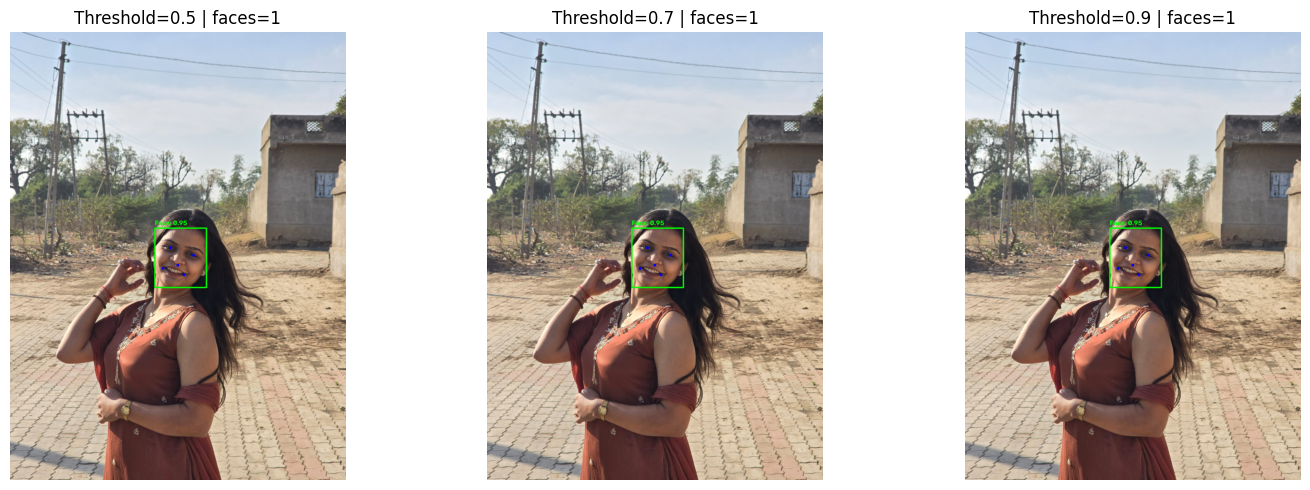

   score_threshold  faces_detected
0              0.5               1
1              0.7               1
2              0.9               1


In [ ]:
thresholds = [0.5, 0.7, 0.9]

if face_files:
    test_face = load_image(face_files[0])
    threshold_rows = []

    plt.figure(figsize=(15, 5))

    for i, threshold in enumerate(thresholds, 1):
        annotated, faces = detect_yunet(test_face, score_threshold=threshold)
        count = 0 if faces is None else len(faces)
        threshold_rows.append({"score_threshold": threshold, "faces_detected": count})

        plt.subplot(1, 3, i)
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        plt.title(f"Threshold={threshold} | faces={count}")
        plt.axis("off")

    plt.tight_layout()
    savefig("task3_threshold_experiment.png")
    plt.show()

    print(pd.DataFrame(threshold_rows))
else:
    print("Add face images first.")


face1.jpg: shape=(1600, 1200, 3), dtype=uint8
Saved: c:\Deep Learning\PR-3\plots\task3_face_blur.png


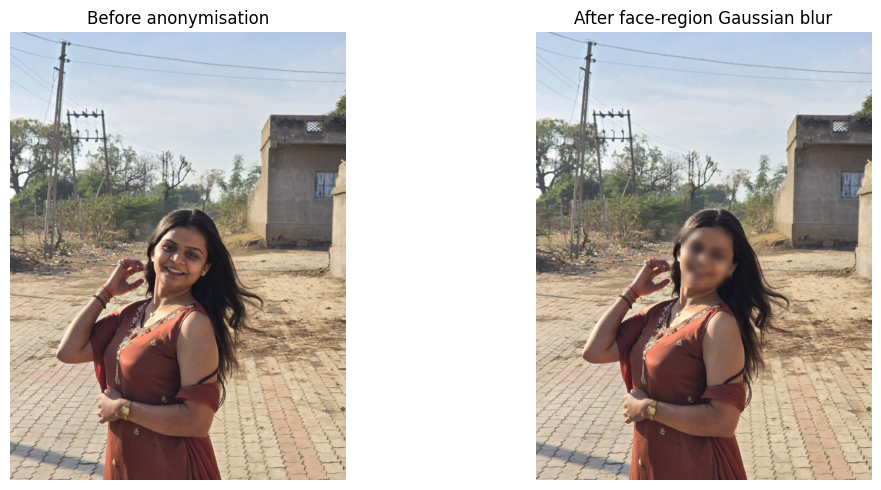

In [ ]:
def blur_detected_faces(image, faces, ksize=(51, 51)):
    output = image.copy()
    if faces is None:
        return output

    h, w = output.shape[:2]
    for face in faces:
        x, y, fw, fh = face[:4].astype(int)

        x1 = max(0, x)
        y1 = max(0, y)
        x2 = min(w, x + fw)
        y2 = min(h, y + fh)

        if x2 > x1 and y2 > y1:
            roi = output[y1:y2, x1:x2]
            output[y1:y2, x1:x2] = cv2.GaussianBlur(roi, ksize, 0)

    return output

if face_files:
    test_face = load_image(face_files[0])
    detector = create_yunet(test_face, 0.7)
    _, faces = detector.detect(test_face)
    blurred = blur_detected_faces(test_face, faces)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(test_face, cv2.COLOR_BGR2RGB))
    plt.title("Before anonymisation")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
    plt.title("After face-region Gaussian blur")
    plt.axis("off")
    plt.tight_layout()
    savefig("task3_face_blur.png")
    plt.show()


### Why YuNet?

YuNet is a compact CNN-based face detector exposed in OpenCV through `FaceDetectorYN`. It is designed for efficient face detection and also returns five facial landmarks in the same detection output.

The **score threshold** controls the precision/recall trade-off:

- Lower threshold → more candidate detections, including more possible false positives.
- Higher threshold → fewer, more confident detections, but small/occluded faces may be missed.

For a real-time security camera, a middle/high threshold such as **0.7–0.9** can be a practical starting point, followed by testing on the actual camera environment. For offline photo tagging, a lower threshold may be useful if missing a face is more costly than reviewing false positives.


# Task 4 — Object Detection with YOLOv8n

### Objective
Use pretrained YOLOv8 Nano to detect multiple COCO object classes and study confidence/IoU threshold effects.

### Expected output
Static-image detections, real-time YOLO, confidence/IoU experiments, per-class detection counts and a YOLO explanation.


In [ ]:
from ultralytics import YOLO

yolo_model = YOLO("yolov8n.pt")
print("YOLOv8n loaded.")


YOLOv8n loaded.


Saved: c:\Deep Learning\PR-3\plots\task4_yolo_static.png


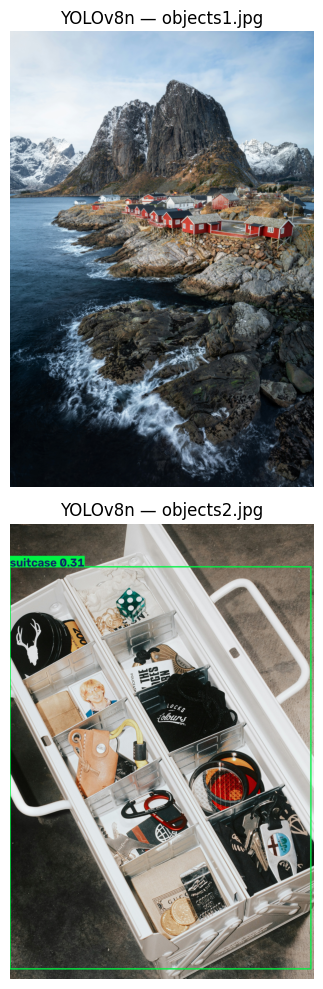

In [ ]:
object_candidates = [
    "objects1.jpg", "objects2.jpg", "objects3.jpg"
]
object_files = [f for f in object_candidates if (IMG_DIR / f).exists()]

if not object_files:
    object_files = [f for f in image_files if "object" in f.lower()][:3]

if not object_files:
    print("No objects1.jpg/objects2.jpg/... found.")
    print("Add 2-3 object images to data/images/ and run again.")
else:
    plt.figure(figsize=(14, 5 * len(object_files)))

    for i, fname in enumerate(object_files, 1):
        result = yolo_model.predict(
            source=str(IMG_DIR / fname),
            conf=0.25,
            iou=0.5,
            verbose=False
        )[0]

        annotated = result.plot()

        plt.subplot(len(object_files), 1, i)
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        plt.title(f"YOLOv8n — {fname}")
        plt.axis("off")

    plt.tight_layout()
    savefig("task4_yolo_static.png")
    plt.show()


In [ ]:
def run_yolo_webcam(camera_index=0, conf=0.25, iou=0.5):
    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened():
        print("Could not open webcam. Try camera_index=1 or check permissions.")
        return

    fps_values = []

    while True:
        ret, frame = cap.read()
        if not ret:
            print("Could not read webcam frame.")
            break

        start = time.perf_counter()

        result = yolo_model.predict(
            source=frame,
            conf=conf,
            iou=iou,
            verbose=False
        )[0]

        annotated = result.plot()
        elapsed = time.perf_counter() - start
        fps = 1.0 / max(elapsed, 1e-9)
        fps_values.append(fps)

        cv2.putText(
            annotated, f"YOLO FPS: {fps:.1f}",
            (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2
        )

        cv2.imshow("YOLOv8n - Press Q", annotated)

        if cv2.waitKey(1) & 0xFF in [ord("q"), ord("Q")]:
            break

    cap.release()
    cv2.destroyAllWindows()

    if fps_values:
        print(f"Average YOLOv8n FPS: {np.mean(fps_values):.2f}")

# Uncomment to run:
# run_yolo_webcam()


,experiment,value,boxes
0,confidence,0.25,0
1,confidence,0.50,0
2,confidence,0.75,0
3,IoU,0.30,0
4,IoU,0.50,0
5,IoU,0.70,0


Saved: c:\Deep Learning\PR-3\plots\task4_threshold_experiment.png


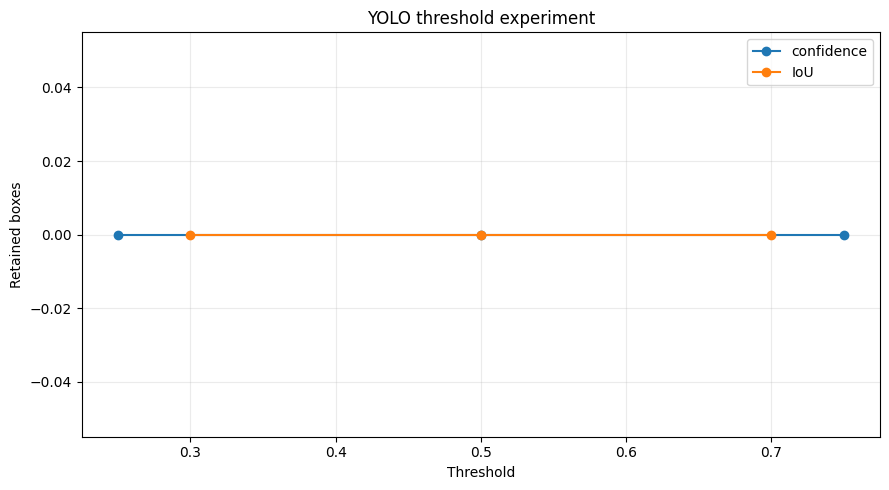

In [ ]:
conf_values = [0.25, 0.5, 0.75]
iou_values = [0.3, 0.5, 0.7]

if object_files:
    test_object_path = str(IMG_DIR / object_files[0])

    rows = []
    for conf in conf_values:
        result = yolo_model.predict(test_object_path, conf=conf, iou=0.5, verbose=False)[0]
        n = len(result.boxes)
        rows.append({"experiment": "confidence", "value": conf, "boxes": n})

    for iou in iou_values:
        result = yolo_model.predict(test_object_path, conf=0.25, iou=iou, verbose=False)[0]
        n = len(result.boxes)
        rows.append({"experiment": "IoU", "value": iou, "boxes": n})

    threshold_df = pd.DataFrame(rows)
    display(threshold_df)

    plt.figure(figsize=(9, 5))
    for exp in ["confidence", "IoU"]:
        part = threshold_df[threshold_df["experiment"] == exp]
        plt.plot(part["value"], part["boxes"], marker="o", label=exp)

    plt.xlabel("Threshold")
    plt.ylabel("Retained boxes")
    plt.title("YOLO threshold experiment")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    savefig("task4_threshold_experiment.png")
    plt.show()
else:
    print("Add an object image first.")


,class,detections
0,suitcase,1


Saved: c:\Deep Learning\PR-3\plots\task4_per_class_summary.png


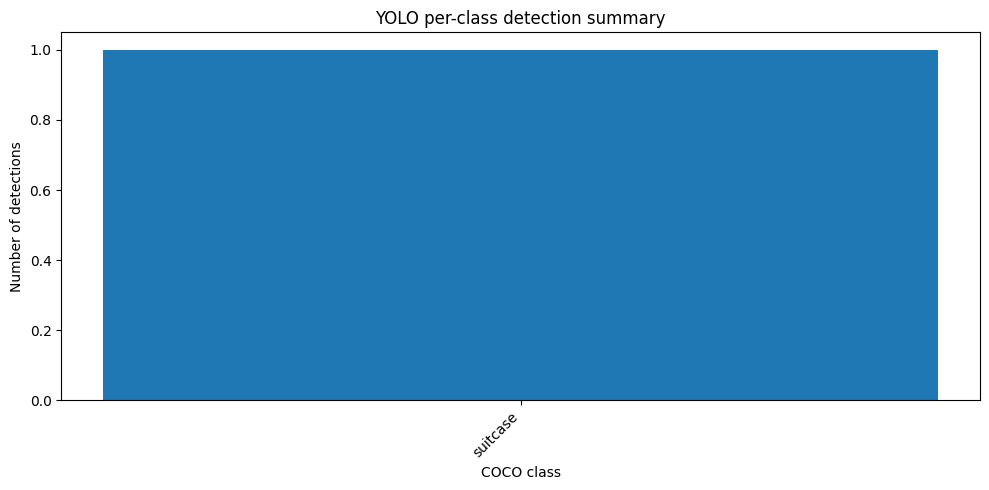

In [ ]:


class_counts = {}

if object_files:
    for fname in object_files:
        result = yolo_model.predict(
            str(IMG_DIR / fname),
            conf=0.25,
            iou=0.5,
            verbose=False
        )[0]

        for cls_id in result.boxes.cls.cpu().numpy().astype(int):
            class_name = yolo_model.names[int(cls_id)]
            class_counts[class_name] = class_counts.get(class_name, 0) + 1

    class_df = pd.DataFrame(
        sorted(class_counts.items(), key=lambda x: x[1], reverse=True),
        columns=["class", "detections"]
    )

    display(class_df)

    if not class_df.empty:
        plt.figure(figsize=(10, 5))
        plt.bar(class_df["class"], class_df["detections"])
        plt.xlabel("COCO class")
        plt.ylabel("Number of detections")
        plt.title("YOLO per-class detection summary")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        savefig("task4_per_class_summary.png")
        plt.show()
else:
    print("Add object images first.")


### Why YOLO generalises

YOLO is a **single-stage object detector**. Instead of using a separate proposal stage followed by classification, it predicts object locations and class probabilities in one forward inference pipeline, followed by post-processing such as Non-Maximum Suppression (NMS).

**YOLOv8n (Nano)** is designed for speed and lower computation. Larger variants such as **YOLOv8s/m/l/x** generally provide more capacity and can improve accuracy, but they require more computation and memory.

The pretrained COCO model can recognise **80 object classes**, so one model can detect many everyday objects without training a separate model for each class.


# Task 5 — Integrated Pipeline & Final Comparison

### Objective
Combine YuNet face detection and YOLO object detection on the same webcam stream and compare their speed.

### Expected output
One integrated live stream, separate/combined FPS measurements, a comparison table and a final deployment reflection.


In [ ]:
def run_integrated_webcam(camera_index=0, face_threshold=0.7, yolo_conf=0.25, yolo_iou=0.5):
    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened():
        print("Could not open webcam.")
        return

    face_detector = None
    fps_values = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        start = time.perf_counter()

        # YuNet
        if face_detector is None:
            face_detector = create_yunet(frame, face_threshold)
        else:
            face_detector.setInputSize((frame.shape[1], frame.shape[0]))

        _, faces = face_detector.detect(frame)
        combined, face_count = draw_yunet(frame, faces)

        # YOLO
        yolo_result = yolo_model.predict(
            source=combined,
            conf=yolo_conf,
            iou=yolo_iou,
            verbose=False
        )[0]
        combined = yolo_result.plot()

        elapsed = time.perf_counter() - start
        fps = 1.0 / max(elapsed, 1e-9)
        fps_values.append(fps)

        cv2.putText(
            combined,
            f"Integrated FPS: {fps:.1f} | Faces: {face_count}",
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.75,
            (0, 255, 0),
            2
        )

        cv2.imshow("Integrated YuNet + YOLO - Press Q", combined)

        if cv2.waitKey(1) & 0xFF in [ord("q"), ord("Q")]:
            break

    cap.release()
    cv2.destroyAllWindows()

    if fps_values:
        print(f"Average integrated FPS: {np.mean(fps_values):.2f}")

# Uncomment to run:
# run_integrated_webcam()


In [ ]:

def benchmark_yunet(camera_index=0, seconds=10, threshold=0.7):
    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened():
        return np.nan

    detector = None
    frames = 0
    start_total = time.perf_counter()

    while time.perf_counter() - start_total < seconds:
        ret, frame = cap.read()
        if not ret:
            break

        if detector is None:
            detector = create_yunet(frame, threshold)
        else:
            detector.setInputSize((frame.shape[1], frame.shape[0]))

        detector.detect(frame)
        frames += 1

    cap.release()
    return frames / max(time.perf_counter() - start_total, 1e-9)

def benchmark_yolo(camera_index=0, seconds=10, conf=0.25, iou=0.5):
    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened():
        return np.nan

    frames = 0
    start_total = time.perf_counter()

    while time.perf_counter() - start_total < seconds:
        ret, frame = cap.read()
        if not ret:
            break

        yolo_model.predict(frame, conf=conf, iou=iou, verbose=False)
        frames += 1

    cap.release()
    return frames / max(time.perf_counter() - start_total, 1e-9)

# For an actual benchmark, run:
# yunet_fps = benchmark_yunet()
# yolo_fps = benchmark_yolo()
# print("YuNet FPS:", yunet_fps)
# print("YOLO FPS:", yolo_fps)

fps_results = pd.DataFrame({
    "Technique": ["YuNet face", "YOLOv8n", "Integrated YuNet + YOLO"],
    "FPS": [0, 0, 0]  
})
display(fps_results)


,Technique,FPS
0,YuNet face,0
1,YOLOv8n,0
2,Integrated YuNet + YOLO,0


Saved: c:\Deep Learning\PR-3\plots\task5_fps_comparison.png


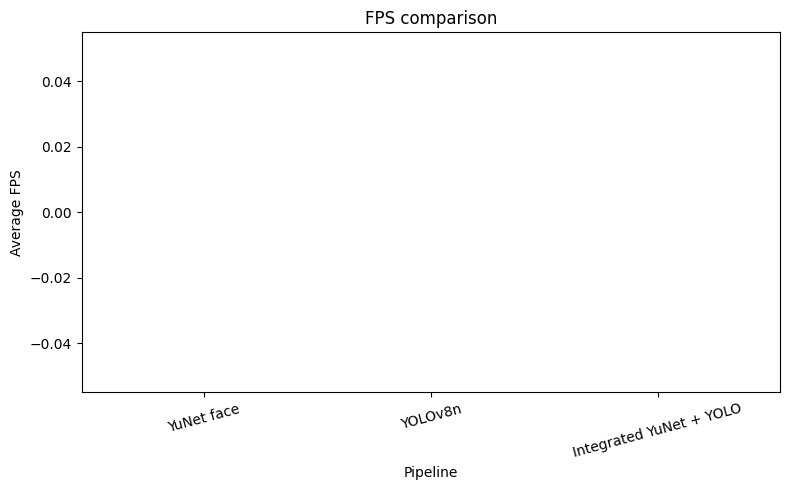

In [30]:

plt.figure(figsize=(8, 5))
plt.bar(fps_results["Technique"], fps_results["FPS"])
plt.xlabel("Pipeline")
plt.ylabel("Average FPS")
plt.title("FPS comparison")
plt.xticks(rotation=15)
plt.tight_layout()
savefig("task5_fps_comparison.png")
plt.show()


In [ ]:
comparison = pd.DataFrame([
    {
        "Technique": "Morphology",
        "Type": "Classical",
        "Detects": "Binary shapes / mask regions",
        "Lighting robustness": "Low–medium",
        "Approx. FPS": "Very high / image-operation dependent",
        "Best use case": "Noise removal and mask cleanup"
    },
    {
        "Technique": "Bitwise operations",
        "Type": "Classical",
        "Detects": "Logical mask regions",
        "Lighting robustness": "Low",
        "Approx. FPS": "Very high",
        "Best use case": "Masking, compositing and ROI extraction"
    },
    {
        "Technique": "Histograms + alpha/beta",
        "Type": "Classical",
        "Detects": "Not a detector",
        "Lighting robustness": "Diagnostic tool",
        "Approx. FPS": "Very high",
        "Best use case": "Brightness/contrast analysis and preprocessing"
    },
    {
        "Technique": "YuNet",
        "Type": "Deep Learning",
        "Detects": "Faces + 5 landmarks",
        "Lighting robustness": "Medium–high",
        "Approx. FPS": "Measure on your system",
        "Best use case": "Real-time face detection"
    },
    {
        "Technique": "YOLOv8n",
        "Type": "Deep Learning",
        "Detects": "80 COCO object classes",
        "Lighting robustness": "Medium–high",
        "Approx. FPS": "Measure on your system",
        "Best use case": "General real-time object detection"
    },
])

display(comparison)
comparison.to_csv(PLOTS_DIR / "final_comparison.csv", index=False)


,Technique,Type,Detects,Lighting robustness,Approx. FPS,Best use case
0,Morphology,Classical,Binary shapes / mask regions,Low–medium,Very high / image-operation dependent,Noise removal and mask cleanup
1,Bitwise operations,Classical,Logical mask regions,Low,Very high,"Masking, compositing and ROI extraction"
2,Histograms + alpha/beta,Classical,Not a detector,Diagnostic tool,Very high,Brightness/contrast analysis and preprocessing
3,YuNet,Deep Learning,Faces + 5 landmarks,Medium–high,Measure on your system,Real-time face detection
4,YOLOv8n,Deep Learning,80 COCO object classes,Medium–high,Measure on your system,General real-time object detection


## Final reflection — model answer

For a **real-time monitoring system**, a good accuracy-to-computation approach is to use inexpensive classical preprocessing only when it is actually needed, followed by a compact deep-learning detector. For face-focused monitoring, **YuNet** is appropriate because it is lightweight and directly provides facial landmarks. For general objects, **YOLOv8n** provides broad COCO-class coverage.

For a **low-power edge device**, I would first keep YOLOv8n and optimise camera resolution, confidence threshold and preprocessing. If more accuracy is required and the hardware can support it, I would test YOLOv8s. For a cloud/server deployment, a larger YOLO model can be considered because computation and memory constraints are less restrictive.

The final choice should be based on **measured FPS, detection accuracy, false positives and the actual camera environment**, rather than assuming one threshold or model is best for every system.
